In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e6/train.csv
/kaggle/input/competitions/playground-series-s6e6/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')

In [3]:
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [4]:
df.shape

(577347, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [6]:
df.isnull().sum()

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

In [7]:
df['spectral_type'].value_counts()

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

In [8]:
df['galaxy_population'].value_counts()

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

In [9]:
df['class'].value_counts()

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

In [10]:
print(df['alpha'].max())
print(df['alpha'].min())

359.999809770956
0.0116837460479923


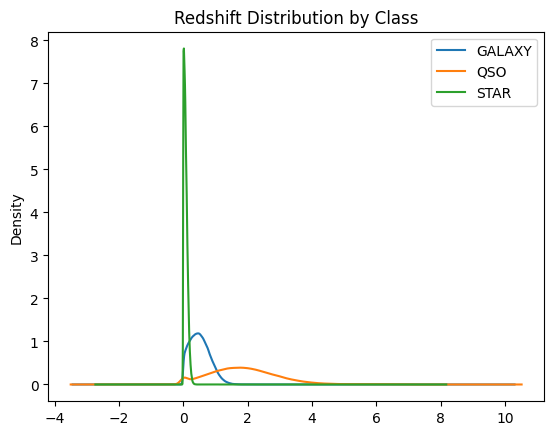

In [11]:
# Option 3 - KDE plot (best to see full separation)
for cls in df['class'].unique():
    df[df['class'] == cls]['redshift'].plot(kind='kde', label=cls)
plt.legend()
plt.title('Redshift Distribution by Class')
plt.show()

<Axes: xlabel='redshift', ylabel='Density'>

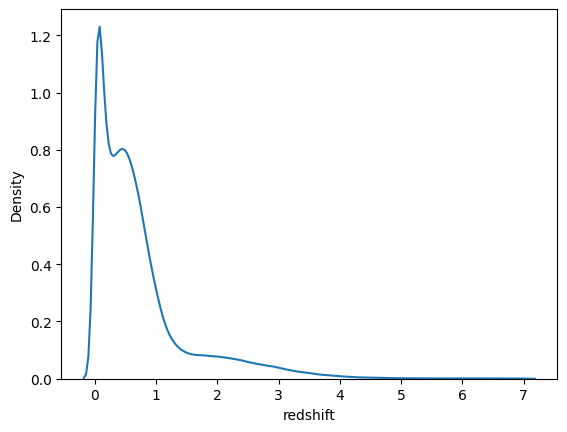

In [12]:
sns.kdeplot(df['redshift'])

In [13]:
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [14]:
# feature engg part

df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

In [15]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

In [16]:
# splitting the data

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

le = LabelEncoder()

y = le.fit_transform(df['class'])

X = df.drop(columns=['class', 'id'])

X = pd.get_dummies(
    X,
    columns=['spectral_type'],
    drop_first=False
)

X = pd.get_dummies(
    X,
    columns=['galaxy_population'],
    drop_first=False
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    score = balanced_accuracy_score(y_valid, preds)

    print(f"Fold {fold}: {score:.5f}")

0:	learn: 0.9165709	total: 362ms	remaining: 6m 1s
100:	learn: 0.9534833	total: 29.8s	remaining: 4m 25s
200:	learn: 0.9593463	total: 58.8s	remaining: 3m 53s
300:	learn: 0.9620570	total: 1m 27s	remaining: 3m 23s
400:	learn: 0.9635855	total: 1m 56s	remaining: 2m 53s
500:	learn: 0.9647677	total: 2m 25s	remaining: 2m 24s
600:	learn: 0.9655623	total: 2m 53s	remaining: 1m 55s
700:	learn: 0.9662508	total: 3m 22s	remaining: 1m 26s
800:	learn: 0.9669371	total: 3m 51s	remaining: 57.5s
900:	learn: 0.9676429	total: 4m 19s	remaining: 28.6s
999:	learn: 0.9681820	total: 4m 48s	remaining: 0us
Fold 1: 0.95006
0:	learn: 0.9173027	total: 293ms	remaining: 4m 52s
100:	learn: 0.9537258	total: 29.1s	remaining: 4m 19s
200:	learn: 0.9594199	total: 58.1s	remaining: 3m 51s
300:	learn: 0.9620202	total: 1m 26s	remaining: 3m 21s
400:	learn: 0.9636159	total: 1m 55s	remaining: 2m 52s
500:	learn: 0.9647287	total: 2m 23s	remaining: 2m 23s
600:	learn: 0.9654670	total: 2m 53s	remaining: 1m 54s
700:	learn: 0.9662356	total:

In [17]:
print(X.dtypes)

alpha                             float64
delta                             float64
u                                 float64
g                                 float64
r                                 float64
i                                 float64
z                                 float64
redshift                          float64
u_g                               float64
g_r                               float64
r_i                               float64
i_z                               float64
spectral_type_A/F                    bool
spectral_type_G/K                    bool
spectral_type_M                      bool
spectral_type_O/B                    bool
galaxy_population_Blue_Cloud         bool
galaxy_population_Red_Sequence       bool
dtype: object


In [18]:
feature_importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

                           feature  importance
7                         redshift   33.345245
0                            alpha   10.073004
9                              g_r    9.262718
1                            delta    8.215097
6                                z    7.780086
10                             r_i    6.620688
8                              u_g    5.964653
2                                u    4.183594
3                                g    4.028311
11                             i_z    3.554720
4                                r    2.491506
5                                i    2.125707
14                 spectral_type_M    0.997364
17  galaxy_population_Red_Sequence    0.531222
16    galaxy_population_Blue_Cloud    0.409706
13               spectral_type_G/K    0.255827
15               spectral_type_O/B    0.094406
12               spectral_type_A/F    0.066144


In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score
import numpy as np

scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    model = XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        tree_method='hist',
        early_stopping_rounds=100,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=100
    )

    preds = model.predict(X_valid)

    score = balanced_accuracy_score(y_valid, preds)
    scores.append(score)

    print(f"Fold {fold}: {score:.5f}")
    print(f"Best iteration: {model.best_iteration}")

print(f"\nMean CV Score: {np.mean(scores):.5f}")

[0]	validation_0-mlogloss:0.82137
[100]	validation_0-mlogloss:0.12171
[200]	validation_0-mlogloss:0.10287
[300]	validation_0-mlogloss:0.09756
[400]	validation_0-mlogloss:0.09446
[500]	validation_0-mlogloss:0.09264
[600]	validation_0-mlogloss:0.09155
[700]	validation_0-mlogloss:0.09066
[800]	validation_0-mlogloss:0.09018
[900]	validation_0-mlogloss:0.08984
[1000]	validation_0-mlogloss:0.08968
[1100]	validation_0-mlogloss:0.08953
[1200]	validation_0-mlogloss:0.08949
[1300]	validation_0-mlogloss:0.08945
[1400]	validation_0-mlogloss:0.08938
[1500]	validation_0-mlogloss:0.08943
[1513]	validation_0-mlogloss:0.08942
Fold 1: 0.95474
Best iteration: 1413
[0]	validation_0-mlogloss:0.82133
[100]	validation_0-mlogloss:0.12233
[200]	validation_0-mlogloss:0.10391
[300]	validation_0-mlogloss:0.09842
[400]	validation_0-mlogloss:0.09529
[500]	validation_0-mlogloss:0.09338
[600]	validation_0-mlogloss:0.09234
[700]	validation_0-mlogloss:0.09149
[800]	validation_0-mlogloss:0.09100
[900]	validation_0-mlogl

In [20]:
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')

In [21]:
test_df['u_g'] = test_df['u'] - test_df['g']
test_df['g_r'] = test_df['g'] - test_df['r']
test_df['r_i'] = test_df['r'] - test_df['i']
test_df['i_z'] = test_df['i'] - test_df['z']

In [22]:
X_test = test_df.drop(columns=['id'])

X_test = pd.get_dummies(
    X_test,
    columns=['spectral_type', 'galaxy_population'],
    drop_first=False
)

In [23]:
X_test = X_test.reindex(
    columns=X.columns,
    fill_value=0
)

In [24]:
final_model = XGBClassifier(
    n_estimators=1400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    tree_method='hist',
    random_state=42
)

final_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1400,
              n_jobs=None, num_class=3, ...)

In [25]:
preds = final_model.predict(X_test)

In [26]:
pred_labels = le.inverse_transform(preds)

In [27]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'class': pred_labels
})

submission.to_csv('submission.csv', index=False)

print(submission.head())

       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
